In [1]:
import os
import numpy as np
from pydicom import dcmread
from icecream import ic
from skimage import morphology
from scipy import ndimage
# from skimage.measure import label, find_contours
import pickle
from numba import jit
import SimpleITK as sitk
from concurrent.futures import ProcessPoolExecutor
from time import time
import json
import nibabel as nib

In [2]:
unsymmetric = np.load('Experiments/QualityFiltered/MOL-101.npy')

In [3]:
def center_scan_on_hw_plane(volume_seq: np.ndarray) -> np.ndarray:
    """
    Centers a preprocessed 4D scan (T, D, H, W) on the H-W plane.
    The centering is based on the centroid of a reference slice.
    It assumes the input scan is skull-stripped with background values of 0.

    Args:
        volume_seq (np.ndarray): The 4D input scan, typically with shape 
                                 (Time, Depth, Height, Width).
                                 Background is assumed to be 0.

    Returns:
        np.ndarray: The centered 4D scan. Returns the original scan if
                    the reference slice is empty or centroid calculation fails.
    """
    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim_size, W_dim_size = volume_seq.shape

    # Select the reference slice (middle volume, middle depth slice)
    ref_time_idx = T // 2
    ref_depth_idx = D // 2
    reference_slice = volume_seq[ref_time_idx, ref_depth_idx, :, :]

    # Calculate the centroid of the brain in the reference slice
    # ndimage.center_of_mass returns (h_coord, w_coord)
    binary_reference_mask = reference_slice > 0  # Or use a specific threshold if needed, e.g., > 0.01

    if np.sum(binary_reference_mask) == 0:
        print("Warning: Binary mask of reference slice is empty. Returning original scan.")
        return np.copy(volume_seq)

    try:
        centroid_h, centroid_w = ndimage.center_of_mass(binary_reference_mask)
    except Exception as e:
        print(f"Warning: Error calculating center_of_mass: {e}. Returning original scan.")
        return np.copy(volume_seq)

    # Desired center of the H-W plane.
    # For an image of size N, pixel indices 0 to N-1, the geometric center is (N-1)/2.0
    actual_H_dim_size = reference_slice.shape[0]
    actual_W_dim_size = reference_slice.shape[1]
    
    target_center_h = (actual_H_dim_size - 1) / 2.0
    target_center_w = (actual_W_dim_size - 1) / 2.0

    # Calculate the shift needed
    shift_h = target_center_h - centroid_h
    shift_w = target_center_w - centroid_w

    # Prepare the output array
    centered_volume_seq = np.zeros_like(volume_seq)

    # Apply the same 2D shift to all H-W slices in the 4D volume
    for t in range(T):
        for d_idx in range(D): # Renamed d to d_idx to avoid conflict with scipy.ndimage
            current_slice = volume_seq[t, d_idx, :, :]
            # Apply shift with bilinear interpolation and 0 padding for background
            centered_slice = ndimage.shift(
                current_slice,
                shift=(shift_h, shift_w), # Shift for (Height, Width) axes
                order=1,                  # Bilinear interpolation
                mode='constant',
                cval=0.0                  # Background value, assuming normalized input
            )
            centered_volume_seq[t, d_idx, :, :] = centered_slice
            
    return centered_volume_seq

In [4]:
centered = center_scan_on_hw_plane(unsymmetric)

In [5]:
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact

def multi_vol_seq_interactive(volume_seqs, titles=None):
    """
    Interactive plot of multiple volume sequences using ipywidgets
    
    Parameters:
    - volume_seqs: List of 4D volume sequences to display
    - titles: Optional list of titles for each sequence
    """
    print(len(volume_seqs))
    if titles is None:
        titles = [f"Volume {i+1}" for i in range(len(volume_seqs))]
        
    num_volumes = len(volume_seqs)
    nrows = int(num_volumes ** 0.5)
    ncols = (num_volumes + nrows - 1) // nrows
    
    # Calculate global min/max for consistent scaling
    global_min = min(np.min(vol) for vol in volume_seqs)
    global_max = max(np.max(vol) for vol in volume_seqs)
    
    def plot_volumes(time_idx, slice_idx):
        fig, axes = plt.subplots(nrows, ncols, 
                                figsize=(5*ncols, 5*nrows),
                                squeeze=True)
        if nrows == 1:
            if ncols == 1:
                axes = [[axes]]
            else:
                axes = [axes]
                
        for i, (volume_seq, title) in enumerate(zip(volume_seqs, titles)):
            row, col = i // ncols, i % ncols
            ax = axes[row][col]
            
            t = min(time_idx, len(volume_seq) - 1)
            s = min(slice_idx, len(volume_seq[t]) - 1)
            
            im = ax.imshow(volume_seq[t][s], cmap='magma', 
                          vmin=global_min, vmax=global_max)
            ax.set_title(title)
            plt.colorbar(im, ax=ax)
            
        plt.tight_layout()
        plt.show(block=True)
        
    max_time = max(len(vol) for vol in volume_seqs) - 1
    max_slice = max(len(vol[0]) for vol in volume_seqs) - 1
    
    interact(
        plot_volumes,
        time_idx=IntSlider(min=0, max=max_time, step=1, value=0, description='Time:'),
        slice_idx=IntSlider(min=0, max=max_slice, step=1, value=0, description='Slice:')
    )


In [6]:
multi_vol_seq_interactive([unsymmetric, centered])

2


interactive(children=(IntSlider(value=0, description='Time:', max=17), IntSlider(value=0, description='Slice:'…

In [ ]:
def symmetric_centering(ct_4d: np.ndarray) -> np.ndarray:
    """
    Performs half the translation and rotation of registration transformation
    to horizontally mirrored scan. This leads to a symmetric scan.

In [23]:
def symmetric_centering(
    volume_seq: np.ndarray,
    num_reference_slices: int = 3,
    default_pixel_value: float = 0.0,
    max_step = 0.0625,
    relaxation_factor = 0.5,
    shrink_factors = [2, 1],
    smoothing_sigmas = [2, 0],
    lr = 0.1,
    n_iters = 150,
    gradient_magnitude_tolerance: float = 1e-5, 
    min_step: float = 5e-3,
    multi_res: bool = True,
    ) -> np.ndarray:
    """
    Corrects in-plane (H-W) rotational and translational asymmetry for a 4D volume
    sequence using SimpleITK.
    A single, averaged 2D transformation is derived from a few reference slices
    taken from the top third of the first volume (t=0). This average transform
    is then applied to all H-W slices in the entire 4D sequence.

    Args:
        volume_seq (np.ndarray): The 4D input scan (T, D, H, W).
                                 Assumes values are typically normalized (e.g., [0,1])
                                 and background has a low value (e.g., 0).
        num_reference_slices (int): Number of reference slices to use from the
                                    top third of the first volume.
        default_pixel_value (float): Value for pixels outside the transformed image.
        min_mean_intensity_for_processing (float): Min mean intensity for a reference
                                     slice to be considered for registration.

    Returns:
        np.ndarray: The 4D scan with H-W planes symmetrized using a global transform,
                    with the same dtype as input. Returns original if transform
                    cannot be derived.
    """
    if not isinstance(volume_seq, np.ndarray) or volume_seq.ndim != 4:
        raise ValueError("Input 'volume_seq' must be a 4D NumPy array.")

    T, D, H_dim, W_dim = volume_seq.shape
    symmetrized_volume_seq = np.copy(volume_seq)
    typed_default_pixel_value = volume_seq.dtype.type(default_pixel_value)
    
    start = D - D // 3
    end = min(start + num_reference_slices, D)
    proj_slice = np.sum(volume_seq[0][start:end], axis=0)
    # if np.mean(hw_slice_orig) < min_mean_intensity_for_processing:
    #     print(f"Skipping reference slice (d={ref_d_idx}) due to low mean intensity: {np.mean(hw_slice_orig):.4f}")
    #     continue
    
    if proj_slice.dtype != np.float32:
        proj_slice = proj_slice.astype(np.float32)

    moving_sitk_image = sitk.GetImageFromArray(proj_slice)
    moving_sitk_image.SetSpacing([1.0, 1.0])

    mirrored_proj_slice = np.fliplr(proj_slice).copy()
    fixed_sitk_image = sitk.GetImageFromArray(mirrored_proj_slice)
    fixed_sitk_image.SetSpacing([1.0, 1.0])

    initial_transform = sitk.CenteredTransformInitializer(
        fixed_sitk_image, moving_sitk_image, sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )
    registration_method = sitk.ImageRegistrationMethod()
    registration_method.SetMetricAsMeanSquares()
    
    # Optimizer settings
    registration_method.SetOptimizerAsRegularStepGradientDescent(
        learningRate=lr,
        maximumStepSizeInPhysicalUnits=max_step,
        minStep=min_step,
        numberOfIterations=n_iters,
        gradientMagnitudeTolerance=gradient_magnitude_tolerance,
        relaxationFactor=relaxation_factor,
        
    )

    if multi_res:
        registration_method.SetShrinkFactorsPerLevel(shrinkFactors=shrink_factors)
        registration_method.SetSmoothingSigmasPerLevel(smoothingSigmas=smoothing_sigmas)
        registration_method.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    registration_method.SetInitialTransform(initial_transform, inPlace=True)
    registration_method.SetInterpolator(sitk.sitkLinear)

    try:
        final_transform_full = registration_method.Execute(fixed_sitk_image, moving_sitk_image)
        transform = final_transform_full.GetParameters()
        center_full = final_transform_full.GetCenter()

        angle_half = transform[0] / 2.0
        tx_half = transform[1] / 2.0
        ty_half = transform[2] / 2.0

        global_transform = sitk.Euler2DTransform()
        global_transform.SetAngle(angle_half)
        global_transform.SetTranslation((tx_half, ty_half))
        global_transform.SetCenter((center_full[0], center_full[1]))
    except Exception as e:
        print(f"Error deriving transform: {e}. Returning original scan.")
        return symmetrized_volume_seq # Original copied array

    resampler = sitk.ResampleImageFilter()
    resampler.SetTransform(global_transform)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(float(typed_default_pixel_value)) # Ensure float for SITK

    for t_idx in range(T):
        for d_slice_idx in range(D): # Renamed to avoid confusion with SimpleITK's 'd'
            current_slice_np = volume_seq[t_idx, d_slice_idx, :, :]
            
            # Convert slice to float32 for SITK processing, if not already
            current_slice_sitk = sitk.GetImageFromArray(current_slice_np)
            current_slice_sitk.SetSpacing([1.0, 1.0]) # Important: Ensure consistent physical space

            # Set reference image for resampler to define output space
            resampler.SetReferenceImage(current_slice_sitk)

            try:
                symmetrized_sitk_slice = resampler.Execute(current_slice_sitk)
                symmetrized_slice_np = sitk.GetArrayFromImage(symmetrized_sitk_slice).astype(volume_seq.dtype, copy=False)
                symmetrized_volume_seq[t_idx, d_slice_idx, :, :] = symmetrized_slice_np
            except RuntimeError as e:
                 print(f"Resampling failed for slice (t={t_idx}, d={d_slice_idx}): {e}. Using original slice for this instance.")
                 # symmetrized_volume_seq already contains the original slice here

    print("Global symmetry correction applied.")
    return symmetrized_volume_seq


In [24]:
scan = symmetric_centering(unsymmetric)

Global symmetry correction applied.


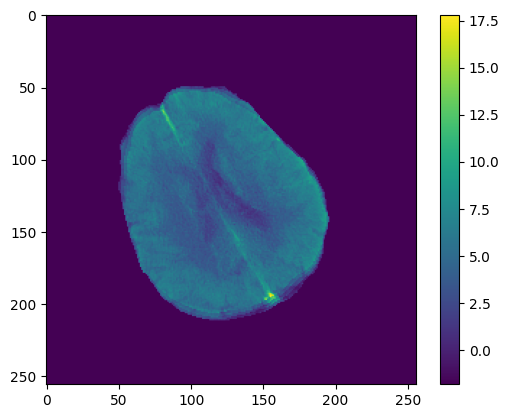

In [18]:
plt.imshow(np.sum(scan[0][-4:], axis=0))
plt.colorbar()